<a href="https://colab.research.google.com/github/sagarkakkar03/Data-science/blob/main/tests_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv('assignment_dataset.csv')
df.head()

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PreferredCategory
0,CUST0001,58,Female,78.0,86.0,Sports
1,CUST0002,25,Other,76.0,71.0,Groceries
2,CUST0003,19,Female,21.0,39.0,Electronics
3,CUST0004,65,Male,38.0,85.0,Electronics
4,CUST0005,35,Female,35.0,14.0,Sports


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         120 non-null    object 
 1   Age                120 non-null    int64  
 2   Gender             115 non-null    object 
 3   AnnualIncome       117 non-null    float64
 4   SpendingScore      119 non-null    float64
 5   PreferredCategory  119 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 5.8+ KB


In [5]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,5
AnnualIncome,3
SpendingScore,1
PreferredCategory,1


In [6]:
df.describe()

,Age,AnnualIncome,SpendingScore
count,120.000000,117.000000,119.000000
mean,44.825000,81.341880,44.420168
std,32.608362,38.959785,32.633428
min,-10.000000,20.000000,-99.000000
25%,30.750000,44.000000,20.500000
50%,40.000000,80.000000,43.000000
75%,56.000000,119.000000,71.000000
max,310.000000,150.000000,100.000000


In [14]:
df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = df['Age'].mean()

/tmp/ipykernel_783/1251290502.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '41.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = df['Age'].mean()


In [20]:
df.loc[(df['SpendingScore'] < 1) | (df['SpendingScore'] > 100), 'SpendingScore'] = df['SpendingScore'].mean()

In [28]:
df['SpendingScore'].fillna(df['SpendingScore'].mean(), inplace=True)
df['AnnualIncome'].fillna(df['AnnualIncome'].mean(), inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['PreferredCategory'].fillna(df['PreferredCategory'].mode()[0], inplace=True)

/tmp/ipykernel_783/948093183.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SpendingScore'].fillna(df['SpendingScore'].mean(), inplace=True)
/tmp/ipykernel_783/948093183.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         120 non-null    object 
 1   Age                120 non-null    float64
 2   Gender             120 non-null    object 
 3   AnnualIncome       120 non-null    float64
 4   SpendingScore      120 non-null    float64
 5   PreferredCategory  120 non-null    object 
dtypes: float64(3), object(3)
memory usage: 5.8+ KB


In [32]:
df['PreferredCategory'].unique()

array(['Sports', 'Groceries', 'Electronics', 'Home Decor', 'Fashion',
       'Health', 'sports'], dtype=object)

In [33]:
df['PreferredCategory'].replace('sports', 'Sports', inplace=True)

In [36]:
df['Gender'].unique()

array(['Female', 'Other', 'Male', 'male', 'female'], dtype=object)

In [40]:
df['Gender'].replace(['male', 'female'], ['Male', 'Female'], inplace=True)

In [42]:
df_gender = pd.get_dummies(df['Gender'])

In [48]:
df_final = pd.concat([df_gender, df.drop(columns=['Gender'])], axis=1)

In [49]:
df_final.head()

,Female,Male,Other,CustomerID,Age,AnnualIncome,SpendingScore,PreferredCategory
0,True,False,False,CUST0001,58.0,78.0,86.0,Sports
1,False,False,True,CUST0002,25.0,76.0,71.0,Groceries
2,True,False,False,CUST0003,19.0,21.0,39.0,Electronics
3,False,True,False,CUST0004,65.0,38.0,85.0,Electronics
4,True,False,False,CUST0005,35.0,35.0,14.0,Sports


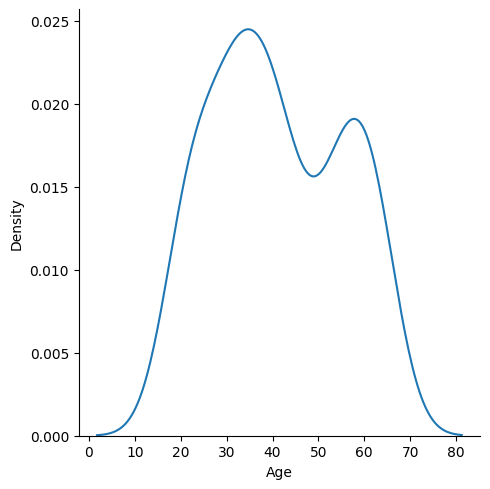

In [53]:
sns.displot(df['Age'], kind='kde')

In [55]:
from scipy.stats import shapiro, pearsonr, ttest_ind, chi2_contingency

In [57]:
_, pvalue = shapiro(df['Age'])
SL = 0.05
if pvalue <= SL:
  print('Not normal')
else:
  print('Normal')

Not normal


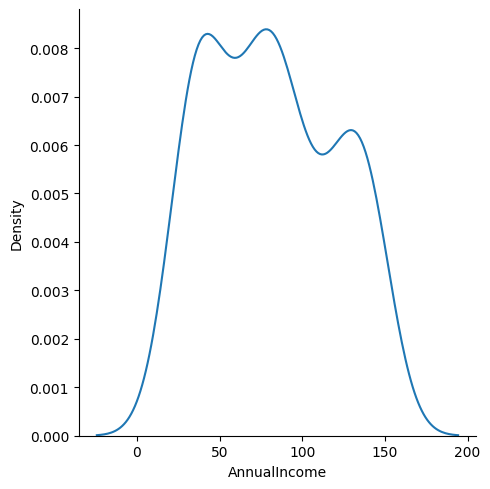

In [58]:
sns.displot(df['AnnualIncome'], kind = 'kde')

In [59]:
_, pvalue = shapiro(df['AnnualIncome'])
if pvalue <= SL:
  print('Not normal')
else:
  print('Normal')

Not normal


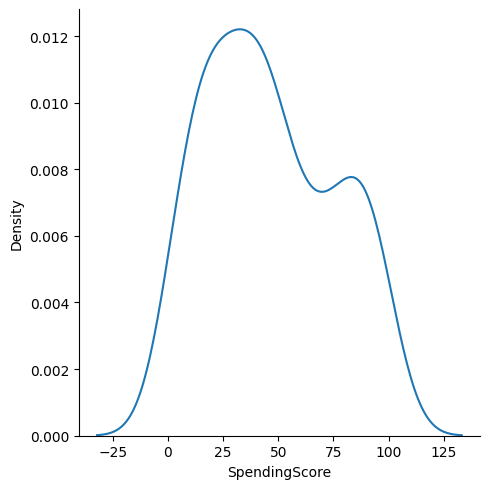

In [61]:
sns.displot(df['SpendingScore'], kind = 'kde')

In [62]:
_, pvalue = shapiro(df['SpendingScore'])
if pvalue <= SL:
  print('Not normal')
else:
  print('Normal')

Not normal


In [63]:
_, pvalue = pearsonr(df['Age'], df['SpendingScore'])
if pvalue <= SL:
  print('There is a relationship')
else:
  print('There is no relationship')

There is no relationship


In [64]:
_, pvalue = ttest_ind(df['Age'], df['SpendingScore'])
if pvalue <= SL:
  print('Can be eliminated')
else:
  print('Can\'t be eliminate')

Can't be eliminate
